# Práctica N° 04 – Generación de Variables Aleatorias Continuas
**Curso:** Simulación Computacional — Escuela de Ingeniería, Universidad de los Llanos
**Estudiante:** David Andres Monroy Aguiar
**Código estudiantil:** 160005019

En este notebook se desarrolla la Práctica N° 04, que consiste en generar variables aleatorias
continuas usando los métodos vistos en clase (transformada inversa, rechazo y polar) y, además,
simular procesos de Poisson y procesos de Poisson no homogéneos. Todo el desarrollo sigue de cerca
el Capítulo 5 de Ross, *Simulation* (5ª ed.).

Para no depender de `numpy.random` ni de ninguna función "caja negra" de generación de aleatorios,
se construyó desde cero un generador congruencial mixto propio, que es el que se usa para producir
todos los $U(0,1)$ que aparecen en el resto del notebook.


## 1. Generador de números pseudoaleatorios (congruencial mixto)

Antes de generar cualquier distribución hay que tener una buena fuente de números uniformes en
$(0,1)$, así que lo primero que se implementó fue un **generador congruencial mixto** (LCG), que
sigue la recurrencia

$$X_{n+1} = (a\,X_n + c) \bmod m, \qquad U_{n+1} = \frac{X_{n+1}}{m}$$

partiendo de una semilla $X_0$. Se le dice *mixto* porque mezcla una parte multiplicativa
($aX_n$) con una aditiva ($c$); si $c=0$ sería puramente multiplicativo.

Los parámetros usados son los de Numerical Recipes ($a=1664525$, $c=1013904223$, $m=2^{32}$),
porque cumplen el teorema de Hull-Dobell y por lo tanto garantizan periodo completo (la secuencia
recorre los $m$ valores posibles antes de repetirse).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng_state_seed = 20240925  # semilla usada en todo el notebook

class GeneradorCongruencialMixto:
    # LCG: X{n+1} = (a*X_n + c) mod m, U = X/m
    def __init__(self, seed=1, a=1664525, c=1013904223, m=2**32):
        self.a = a
        self.c = c
        self.m = m
        self.x = seed % m

    def uniform(self):
        self.x = (self.a * self.x + self.c) % self.m
        return self.x / self.m

    def sample(self, n):
        return np.array([self.uniform() for _ in range(n)])

gen = GeneradorCongruencialMixto(seed=rng_state_seed)
U_test = gen.sample(10000)
print("Primeros 10 valores generados:", np.round(U_test[:10], 4))
print("Media muestral:", U_test.mean(), " (debería ser cercana a 0.5)")
print("Varianza muestral:", U_test.var(), " (teórica = 1/12 =", 1/12, ")")


Primeros 10 valores generados: [0.6557 0.3865 0.6068 0.154  0.9226 0.2042 0.5863 0.0281 0.3696 0.2311]
Media muestral: 0.5021979385288432  (debería ser cercana a 0.5)
Varianza muestral: 0.08209956809662894  (teórica = 1/12 = 0.08333333333333333 )


Chi-cuadrado calculado = 10.288
Chi-cuadrado crítico (alpha=0.05, df=19) = 30.144
p-value = 0.9455
No se rechaza H0, los datos son uniformes.

Correlación serial (lag 1) = 0.0013 (cercana a 0 = buena señal)


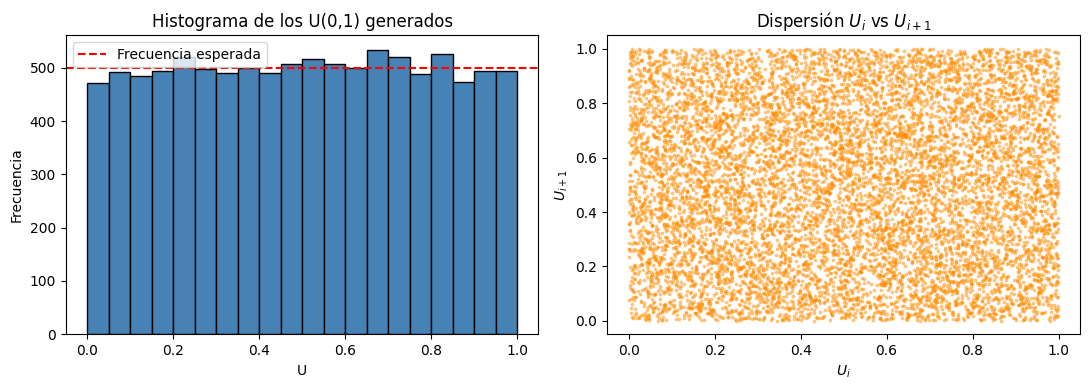

In [ ]:
# Antes de usar este generador conviene comprobar que
# efectivamente se comporta como U(0,1): osea que sea uniforme y que los valores no estén
# correlacionados entre sí (aleatorieadad).

# --- Uniformidad: chi-cuadrado sobre k intervalos ---
k = 20
n = len(U_test)
obs, edges = np.histogram(U_test, bins=k, range=(0, 1))
esperado = n / k
chi2_stat = np.sum((obs - esperado) ** 2 / esperado)
chi2_crit = stats.chi2.ppf(0.95, df=k - 1)
p_value = 1 - stats.chi2.cdf(chi2_stat, df=k - 1)
print(f"Chi-cuadrado calculado = {chi2_stat:.3f}")
print(f"Chi-cuadrado crítico (alpha=0.05, df={k-1}) = {chi2_crit:.3f}")
print(f"p-value = {p_value:.4f}")
print("No se rechaza H0, los datos son uniformes." if chi2_stat < chi2_crit else "Se rechaza H0.")

# --- Independencia: correlación serial y dispersión Ui vs Ui+1 ---
corr = np.corrcoef(U_test[:-1], U_test[1:])[0, 1]
print(f"\nCorrelación serial (lag 1) = {corr:.4f} (cercana a 0 = buena señal)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(U_test, bins=k, edgecolor='black', color='steelblue')
axes[0].axhline(esperado, color='red', linestyle='--', label='Frecuencia esperada')
axes[0].set_title('Histograma de los U(0,1) generados')
axes[0].set_xlabel('U'); axes[0].set_ylabel('Frecuencia'); axes[0].legend()

axes[1].scatter(U_test[:-1], U_test[1:], s=3, alpha=0.4, color='darkorange')
axes[1].set_title('Dispersión $U_i$ vs $U_{i+1}$')
axes[1].set_xlabel('$U_i$'); axes[1].set_ylabel('$U_{i+1}$')
plt.tight_layout()
plt.savefig('gen_uniformidad.png', dpi=120)
plt.show()


El histograma queda bastante parejo entre los 20 intervalos y el chi-cuadrado calculado no
supera al crítico, así que no hay motivo para dudar de la uniformidad. En el diagrama de dispersión
tampoco se ve ningún patrón entre $U_i$ y $U_{i+1}$ (si hubiera correlación se notaría como líneas o
franjas diagonales), así que el generador queda validado para usarlo en el resto de la práctica.


## 2. Consulta previa

**¿Qué es una variable aleatoria?**
Es básicamente una función que le asigna un número real a cada resultado posible de un experimento
aleatorio, es decir $X:\Omega \to \mathbb{R}$. Sirve para poder trabajar numéricamente con algo que
de entrada es incierto. Puede ser discreta (si solo puede tomar un conjunto contable de valores) o
continua (si toma cualquier valor dentro de un intervalo de $\mathbb{R}$).

**¿Qué es una distribución de probabilidad?**
Es la manera de describir cómo se reparte la probabilidad entre los valores que puede tomar una
variable aleatoria. En el caso discreto se usa una función de masa $p(x) = P(X=x)$, y en el caso
continuo una función de densidad $f(x)$, junto con la función de distribución acumulada
$F(x) = P(X \le x)$.

**¿Cuál es la diferencia entre una distribución discreta y una continua?**
En una variable discreta, $X$ solo puede tomar un número finito o numerable de valores y cada uno
tiene una probabilidad puntual mayor que cero ($\sum_i p(x_i) = 1$). En una continua, $X$ puede
tomar cualquier valor dentro de un intervalo, por lo que la probabilidad de un punto exacto es cero
($P(X=x)=0$); las probabilidades se calculan integrando la densidad, $P(a \le X \le b) = \int_a^b
f(x)\,dx$, con $\int_{-\infty}^{\infty} f(x)\,dx = 1$.

**¿Cuál es la definición de la distribución Exponencial?**
Se usa para modelar tiempos de espera entre eventos (por ejemplo, cuánto se demora en llegar el
siguiente cliente). Su densidad es

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0,\ \lambda > 0$$

con $F(x) = 1 - e^{-\lambda x}$, media $1/\lambda$ y varianza $1/\lambda^2$. Tiene la propiedad de
"falta de memoria": $P(X > s+t \mid X > s) = P(X > t)$, es decir que no importa cuánto tiempo ya se
haya esperado, la distribución del tiempo restante es la misma.

**¿Cuál es la definición de la distribución Gamma y sus parámetros?**
Es como una generalización de la exponencial: si se suman $\alpha$ variables exponenciales
independientes con la misma tasa $\lambda$, el resultado es una Gamma($\alpha,\lambda$) (cuando
$\alpha$ es entero se le suele llamar Erlang). Su densidad es

$$f(x) = \frac{\lambda e^{-\lambda x}(\lambda x)^{\alpha-1}}{\Gamma(\alpha)}, \quad x \ge 0$$

$\alpha$ es el parámetro de forma y $\lambda$ el parámetro de tasa; la media es $\alpha/\lambda$ y
la varianza $\alpha/\lambda^2$.

**¿Cuál es la definición de la distribución Normal estándar y sus parámetros?**
La Normal general $N(\mu,\sigma^2)$ tiene densidad

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

donde $\mu$ es la media (centra la campana) y $\sigma$ la desviación estándar (qué tan ancha es la
campana). La Normal **estándar** es el caso particular $\mu=0,\ \sigma=1$:

$$f(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$$

Cualquier $X \sim N(\mu,\sigma^2)$ se puede llevar a la forma estándar con $Z=(X-\mu)/\sigma$.

**¿Qué es un proceso de Poisson y un proceso de Poisson no homogéneo? ¿Cuál es la diferencia entre
ellos?**
Un proceso de Poisson homogéneo con tasa $\lambda$ es un proceso de conteo $\{N(t), t \ge 0\}$
donde el número de eventos que ocurren en un intervalo de longitud $t$ sigue una Poisson de media
$\lambda t$, los eventos en intervalos disjuntos son independientes entre sí, y la tasa $\lambda$
es constante todo el tiempo. Esto es lo mismo que decir que los tiempos entre eventos consecutivos
son variables exponenciales i.i.d. de tasa $\lambda$.

Un proceso de Poisson **no homogéneo** es básicamente lo mismo pero dejando que la tasa cambie con
el tiempo, $\lambda(t)$. El número de eventos en $[t_1,t_2]$ sigue siendo Poisson, pero ahora con
media $m(t_2)-m(t_1) = \int_{t_1}^{t_2} \lambda(s)\,ds$. La diferencia entonces está en que en el
homogéneo la tasa de llegada es fija, y en el no homogéneo depende del instante (por ejemplo, para
representar horas pico donde llegan más clientes que en horas valle).


## 3. Equipos, materiales y reactivos

Todo el trabajo se hizo en Google Colaboratory con Python 3, usando `numpy` y `matplotlib` para el
cálculo y las gráficas, y `scipy` únicamente como referencia para comparar contra funciones de
densidad teóricas (no se usó para generar ningún aleatorio). El generador de números uniformes es
el `GeneradorCongruencialMixto` implementado en la Sección 1.


## 4. Procedimiento y metodología

### 4.1 Generación de variables aleatorias continuas

Para cada literal se generaron 1000 valores, se armó el histograma correspondiente y se comparó
contra la densidad teórica $f(x)$ dibujada como curva continua, para ver qué tan bien queda el
ajuste.


#### a) $f(x) = \frac{e^{x}}{e-1}$, para $0 \le x \le 1$

**Método usado: transformada inversa.**
Integrando la densidad se obtiene $F(x) = \int_0^x \frac{e^t}{e-1}\,dt = \frac{e^{x}-1}{e-1}$.

Haciendo $U=F(X)$ y despejando $X$ queda:

$$U = \frac{e^{X}-1}{e-1} \;\Longrightarrow\; X = \ln\!\big(1 + U(e-1)\big), \quad U\sim U(0,1)$$


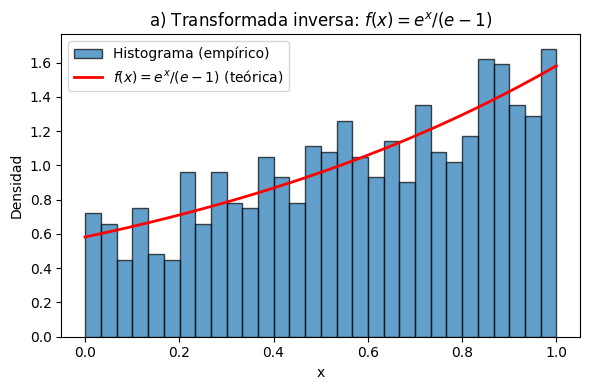

Media muestral: 0.5792523331902107  | Media teórica: 0.5819767068693265


In [ ]:
def genera_a(u):
    return np.log(1 + u * (np.e - 1))

gen_a = GeneradorCongruencialMixto(seed=rng_state_seed + 1)
U = gen_a.sample(1000)
X_a = genera_a(U)

x_teo = np.linspace(0, 1, 400)
f_teo = np.exp(x_teo) / (np.e - 1)

plt.figure(figsize=(6, 4))
plt.hist(X_a, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label='$f(x)=e^x/(e-1)$ (teórica)')
plt.title('a) Transformada inversa: $f(x)=e^x/(e-1)$')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_a.png', dpi=120); plt.show()

# La media teórica se calcula integrando x*f(x) entre 0 y 1: E[X] = 1/(e-1)
media_teorica_a = 1 / (np.e - 1)
print("Media muestral:", X_a.mean(), " | Media teórica:", media_teorica_a)


La forma del histograma queda prácticamente pegada a la curva teórica y la media muestral
sale muy cercana a la media teórica, así que la implementación parece correcta.


#### b) Densidad triangular a trozos

$$f(x)=\begin{cases}\dfrac{x-2}{2}, & 2\le x\le 3\\[4pt] \dfrac{2-x/3}{2}, & 3\le x\le 6\end{cases}$$

Como la densidad está definida por tramos, también hay que integrar por tramos para obtener $F(x)$:

- Para $2\le x\le 3$: $F_1(x) = \frac{(x-2)^2}{4}$, y en $x=3$ da $F_1(3)=0.25$ (esa es la
  probabilidad acumulada hasta el final del primer tramo).
- Para $3\le x\le 6$: $F(x) = x - \frac{x^2}{12} - 2$.

Invirtiendo cada tramo, dado $U\sim U(0,1)$:

$$X=\begin{cases}2+2\sqrt{U}, & 0\le U< 0.25\\[4pt] 6-\sqrt{12(1-U)}, & 0.25\le U\le 1\end{cases}$$

La idea es simple: si $U$ cae antes de 0.25 se usa la fórmula del primer tramo, y si cae después se
usa la del segundo.


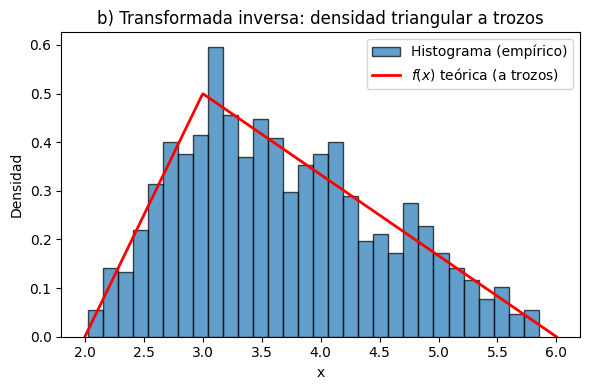

In [ ]:
def genera_b(u):
    u = np.asarray(u)
    x = np.where(u < 0.25,
                 2 + 2*np.sqrt(u),
                 6 - np.sqrt(12*(1 - u)))
    return x

gen_b = GeneradorCongruencialMixto(seed=rng_state_seed + 2)
U = gen_b.sample(1000)
X_b = genera_b(U)

def f_b(x):
    x = np.asarray(x, dtype=float)
    f = np.zeros_like(x)
    m1 = (x >= 2) & (x <= 3)
    m2 = (x > 3) & (x <= 6)
    f[m1] = (x[m1] - 2) / 2
    f[m2] = (2 - x[m2]/3) / 2
    return f

x_teo = np.linspace(2, 6, 400)
plt.figure(figsize=(6, 4))
plt.hist(X_b, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_b(x_teo), 'r-', linewidth=2, label='$f(x)$ teórica (a trozos)')
plt.title('b) Transformada inversa: densidad triangular a trozos')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_b.png', dpi=120); plt.show()


Se ve claramente la forma triangular esperada, con el pico en $x=3$ (donde $f(3)=0.5$) y
cayendo hacia ambos lados. El quiebre en $x=3$ del algoritmo (el "if" sobre $U<0.25$) es justo el
que produce ese pico.


#### c) $F(x) = \frac{x^2+x}{2}$, para $0\le x\le 1$

Acá ya dan la función de distribución directamente, así que solo toca despejar $X$ de $U=F(X)$:

$$U=\frac{X^2+X}{2} \;\Longrightarrow\; X^2+X-2U=0 \;\Longrightarrow\; X=\frac{-1+\sqrt{1+8U}}{2}$$

De las dos soluciones de la cuadrática se toma la raíz positiva, porque la otra da valores negativos
que no tienen sentido dentro del dominio $[0,1]$.


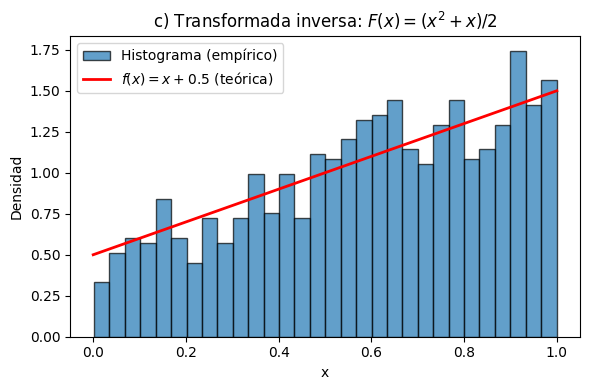

In [ ]:
def genera_c(u):
    return (-1 + np.sqrt(1 + 8*u)) / 2

gen_c = GeneradorCongruencialMixto(seed=rng_state_seed + 3)
U = gen_c.sample(1000)
X_c = genera_c(U)

x_teo = np.linspace(0, 1, 400)
f_teo = x_teo + 0.5  # f(x) = F'(x) = (2x+1)/2 = x + 0.5

plt.figure(figsize=(6, 4))
plt.hist(X_c, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label='$f(x)=x+0.5$ (teórica)')
plt.title('c) Transformada inversa: $F(x)=(x^2+x)/2$')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_c.png', dpi=120); plt.show()


#### d) Distribución de Weibull: $F(x) = 1-\exp(-\alpha x^{\beta})$, para $0<x<\infty$

Despejando $X$ de $U=1-\exp(-\alpha X^\beta)$ se llega a

$$X = \left(\frac{-\ln(1-U)}{\alpha}\right)^{1/\beta}, \quad U\sim U(0,1)$$

Para probar el generador se usaron $\alpha=1$ y $\beta=2$, pero la función quedó armada para
cualquier valor de los parámetros.


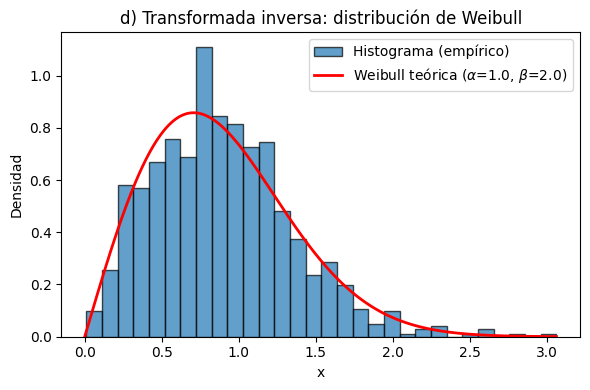

In [ ]:
def genera_weibull(u, alpha=1.0, beta=2.0):
    return (-np.log(1 - u) / alpha) ** (1/beta)

alpha, beta = 1.0, 2.0
gen_d = GeneradorCongruencialMixto(seed=rng_state_seed + 4)
U = gen_d.sample(1000)
X_d = genera_weibull(U, alpha, beta)

x_teo = np.linspace(0.001, X_d.max(), 400)
f_teo = alpha*beta*x_teo**(beta-1)*np.exp(-alpha*x_teo**beta)

plt.figure(figsize=(6, 4))
plt.hist(X_d, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label=f'Weibull teórica ($\\alpha$={alpha}, $\\beta$={beta})')
plt.title('d) Transformada inversa: distribución de Weibull')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_d.png', dpi=120); plt.show()


### Extra: Exponencial, Gamma y Normal estándar

La guía también pide en los objetivos generar Exponencial, Gamma y Normal estándar, aunque no
aparezcan como literales explícitos dentro de la Sección 5.1. Para no dejarlos por fuera se
incluyen aquí también.


#### Exponencial (transformada inversa)

De $F(x)=1-e^{-\lambda x}$ se despeja $X=-\frac{\ln(1-U)}{\lambda}$; como $U$ y $1-U$ tienen
exactamente la misma distribución, en la práctica se suele usar directamente la forma más simple
$X=-\frac{\ln(U)}{\lambda}$.


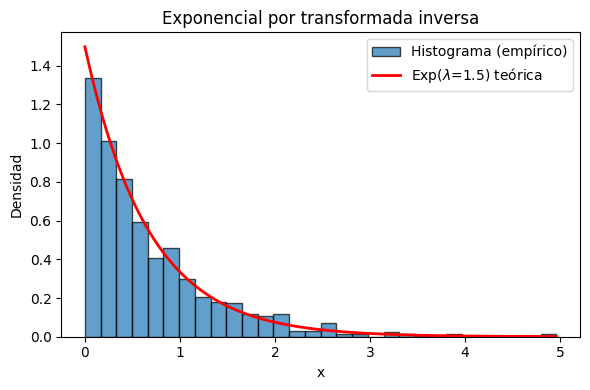

In [ ]:
def genera_exponencial(u, lam=1.0):
    return -np.log(u) / lam

lam = 1.5
gen_e = GeneradorCongruencialMixto(seed=rng_state_seed + 5)
U = gen_e.sample(1000)
X_exp = genera_exponencial(U, lam)

x_teo = np.linspace(0.001, X_exp.max(), 400)
f_teo = lam * np.exp(-lam * x_teo)

plt.figure(figsize=(6, 4))
plt.hist(X_exp, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label=f'Exp($\\lambda$={lam}) teórica')
plt.title('Exponencial por transformada inversa')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_exp.png', dpi=120); plt.show()


#### Gamma (como suma de exponenciales)

Cuando $\alpha=k$ es un número entero, no hace falta un método sofisticado: basta sumar $k$
exponenciales independientes con la misma tasa, $X=\sum_{i=1}^{k} -\frac{\ln(U_i)}{\lambda}$, y el
resultado ya es Gamma($k,\lambda$).


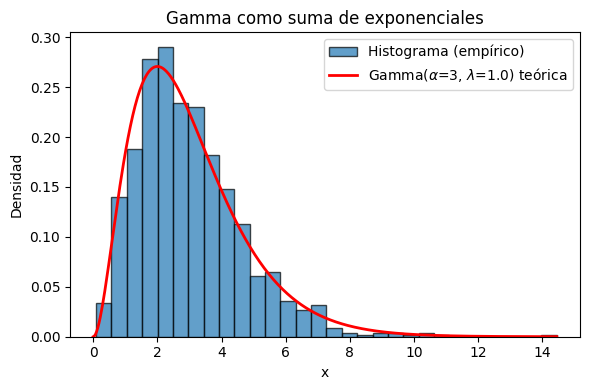

In [ ]:
def genera_gamma_entero(gen, k, lam=1.0):
    U = gen.sample(k)
    return -np.sum(np.log(U)) / lam

k_shape, lam_gamma = 3, 1.0
gen_g = GeneradorCongruencialMixto(seed=rng_state_seed + 6)
X_gamma = np.array([genera_gamma_entero(gen_g, k_shape, lam_gamma) for _ in range(1000)])

from scipy.special import gamma as gamma_fn
x_teo = np.linspace(0.001, X_gamma.max(), 400)
f_teo = (lam_gamma*np.exp(-lam_gamma*x_teo)*(lam_gamma*x_teo)**(k_shape-1)) / gamma_fn(k_shape)

plt.figure(figsize=(6, 4))
plt.hist(X_gamma, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label=f'Gamma($\\alpha$={k_shape}, $\\lambda$={lam_gamma}) teórica')
plt.title('Gamma como suma de exponenciales')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_gamma.png', dpi=120); plt.show()


#### Normal estándar (método polar de Marsaglia)

El método polar es una alternativa a Box-Muller que evita tener que calcular senos y cosenos:

1. Generar $U_1,U_2\sim U(0,1)$ y llevarlos al cuadrado $[-1,1]\times[-1,1]$ con $V_1=2U_1-1$,
   $V_2=2U_2-1$.
2. Calcular $S=V_1^2+V_2^2$. Si $S>1$ el punto cayó fuera del círculo unitario, así que se rechaza
   y se vuelve a intentar (es, de hecho, una aplicación del método del rechazo).
3. Si $S\le 1$, se calcula $X=V_1\sqrt{\frac{-2\ln S}{S}}$ y $Y=V_2\sqrt{\frac{-2\ln S}{S}}$.
4. $X$ y $Y$ salen como dos normales estándar independientes, así que cada intento aceptado da dos
   valores "gratis".


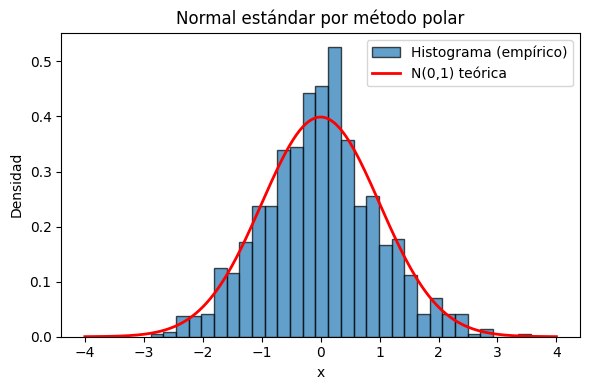

Media: -0.008338145088676271  Varianza: 0.9369443747634117


In [ ]:
def metodo_polar(gen, n):
    valores = []
    while len(valores) < n:
        v1 = 2*gen.uniform() - 1
        v2 = 2*gen.uniform() - 1
        s = v1**2 + v2**2
        if s <= 1 and s > 0:
            factor = np.sqrt(-2*np.log(s)/s)
            valores.append(v1*factor)
            valores.append(v2*factor)
    return np.array(valores[:n])

gen_n = GeneradorCongruencialMixto(seed=rng_state_seed + 7)
X_normal = metodo_polar(gen_n, 1000)

x_teo = np.linspace(-4, 4, 400)
f_teo = (1/np.sqrt(2*np.pi)) * np.exp(-x_teo**2/2)

plt.figure(figsize=(6, 4))
plt.hist(X_normal, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histograma (empírico)')
plt.plot(x_teo, f_teo, 'r-', linewidth=2, label='N(0,1) teórica')
plt.title('Normal estándar por método polar')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout(); plt.savefig('caso_normal.png', dpi=120); plt.show()

print("Media:", X_normal.mean(), " Varianza:", X_normal.var())


### 4.2 Generando procesos de Poisson

#### a) Primeras $T$ unidades de tiempo de un proceso de Poisson homogéneo de tasa $\lambda$

La idea del algoritmo (Ross, Sec. 5.4) es ir generando tiempos entre eventos exponenciales y
sumarlos, hasta pasarse del tiempo límite $T$:

1. $t \leftarrow 0$, contador $I \leftarrow 0$.
2. Generar $U \sim U(0,1)$ y hacer $t \leftarrow t - \frac{\ln U}{\lambda}$ (así se obtiene un
   tiempo entre eventos exponencial).
3. Si $t > T$, parar.
4. Si no, $I \leftarrow I+1$, se guarda el tiempo de arribo $S_I \leftarrow t$, y se vuelve al
   paso 2.


Se generaron 41 eventos en [0, 20] con tasa lambda=2.0
Media teórica de eventos = lambda*T = 40.0
Primeros 10 tiempos de arribo: [0.209 1.303 2.538 2.937 3.622 4.463 6.146 6.66  7.071 7.256]


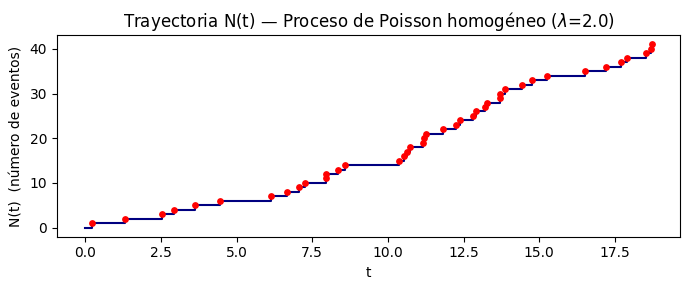

In [ ]:
def poisson_homogeneo(gen, T, lam):
    t = 0.0
    tiempos_arribo = []
    while True:
        u = gen.uniform()
        t = t - np.log(u) / lam
        if t > T:
            break
        tiempos_arribo.append(t)
    return np.array(tiempos_arribo)

T, lam = 20, 2.0
gen_p = GeneradorCongruencialMixto(seed=rng_state_seed + 8)
arribos = poisson_homogeneo(gen_p, T, lam)

print(f"Se generaron {len(arribos)} eventos en [0, {T}] con tasa lambda={lam}")
print("Media teórica de eventos = lambda*T =", lam*T)
print("Primeros 10 tiempos de arribo:", np.round(arribos[:10], 3))

plt.figure(figsize=(7, 3))
plt.step(np.concatenate(([0], arribos)), np.arange(0, len(arribos)+1), where='post', color='navy')
plt.scatter(arribos, np.arange(1, len(arribos)+1), color='red', s=15, zorder=5)
plt.title(f'Trayectoria N(t) — Proceso de Poisson homogéneo ($\\lambda$={lam})')
plt.xlabel('t'); plt.ylabel('N(t)  (número de eventos)')
plt.tight_layout(); plt.savefig('poisson_homogeneo.png', dpi=120); plt.show()


El número de eventos que salió está cerca de $\lambda T$, que es lo que se esperaría en
promedio si se repitiera la simulación muchas veces. La trayectoria en forma de escalera es típica
de un proceso de conteo: sube de a uno cada vez que llega un evento.


#### b) Variable aleatoria de Coxian

Este ejercicio es un poco distinto: un trabajador pasa por $k$ etapas en secuencia, y el tiempo
que se demora en la etapa $i$ es $\text{Exp}(\lambda_i)$. Pero al terminar cada etapa hay una
probabilidad $\alpha_i$ de que siga a la siguiente, y $1-\alpha_i$ de que simplemente se retire.
$X$ es el tiempo total que el trabajador estuvo trabajando.

El algoritmo queda así:

1. $i \leftarrow 1$, $X \leftarrow 0$.
2. Generar $T_i \sim \text{Exp}(\lambda_i)$ (por ejemplo $T_i=-\ln(U)/\lambda_i$) y sumarlo,
   $X\leftarrow X+T_i$.
3. Si ya se llegó a la etapa $k$, parar (se terminaron todas las etapas).
4. Si no, generar $U'\sim U(0,1)$. Si $U' > \alpha_i$, el trabajador se retira y se para ahí.
5. Si no se retiró, pasar a la siguiente etapa ($i \leftarrow i+1$) y volver al paso 2.


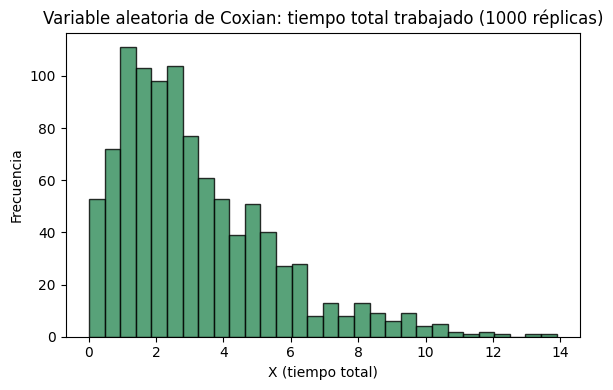

Media muestral de X (Coxian): 3.1695520814679603
Desviación estándar muestral: 2.304144492172755


In [ ]:
def variable_coxian(gen, lambdas, alphas):
    # lambdas: tasa de cada una de las k etapas
    # alphas: probabilidad de continuar tras cada etapa i=1..k-1
    # (no aplica alpha después de la última etapa, porque ahí ya se termina siempre)
    k = len(lambdas)
    X = 0.0
    for i in range(k):
        u = gen.uniform()
        Ti = -np.log(u) / lambdas[i]
        X += Ti
        if i == k - 1:
            break
        u2 = gen.uniform()
        if u2 > alphas[i]:
            break
    return X

lambdas = [1.0, 0.8, 1.2, 0.5]      # tasas de las k=4 etapas (valores de ejemplo)
alphas = [0.9, 0.7, 0.5]             # prob. de continuar tras la etapa 1, 2 y 3

gen_cox = GeneradorCongruencialMixto(seed=rng_state_seed + 9)
X_coxian = np.array([variable_coxian(gen_cox, lambdas, alphas) for _ in range(1000)])

plt.figure(figsize=(6, 4))
plt.hist(X_coxian, bins=30, edgecolor='black', color='seagreen', alpha=0.8)
plt.title('Variable aleatoria de Coxian: tiempo total trabajado (1000 réplicas)')
plt.xlabel('X (tiempo total)'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.savefig('coxian.png', dpi=120); plt.show()

print("Media muestral de X (Coxian):", X_coxian.mean())
print("Desviación estándar muestral:", X_coxian.std())


### 4.3 Generando procesos de Poisson no homogéneos

Ahora la tasa ya no es constante sino que depende del tiempo:

$$\lambda(t)=\begin{cases}t/5, & 0<t<5\\ 1+5(t-5), & 5<t<10\end{cases}$$

Para simular esto se usa el **método del adelgazamiento** (*thinning*, Ross Sec. 5.5), que consiste
en acotar $\lambda(t)$ por una cota superior $\lambda^{*}$ (en este caso $\lambda^{*}=26$, que es el
valor máximo que alcanza $\lambda(t)$ cerca de $t=10$), simular un proceso homogéneo con esa tasa
$\lambda^{*}$, y luego "adelgazar" la secuencia aceptando cada evento propuesto en el instante $t$
solo con probabilidad $\lambda(t)/\lambda^{*}$. Los eventos rechazados simplemente se descartan.

Algoritmo:

1. $t\leftarrow 0$, $I\leftarrow 0$.
2. Generar $U_1\sim U(0,1)$ y hacer $t\leftarrow t-\frac{\ln U_1}{\lambda^{*}}$.
3. Si $t>10$, parar.
4. Generar $U_2\sim U(0,1)$. Si $U_2 \le \lambda(t)/\lambda^{*}$, se acepta el evento:
   $I\leftarrow I+1$, $S_I\leftarrow t$. De todas formas, se vuelve al paso 2.


lambda* (cota superior) = 25.999999995

Se generaron 68 eventos en (0, 10]
Tiempos de arribo: [1.945 2.991 5.229 5.388 5.544 5.611 5.776 6.13  6.157 6.177 6.184 6.577
 6.72  6.899 7.078 7.105 7.161 7.241 7.325 7.337 7.382 7.856 7.948 8.004
 8.086 8.176 8.205 8.274 8.287 8.306 8.368 8.492 8.501 8.535 8.55  8.627
 8.767 8.797 8.797 8.889 8.918 8.928 9.028 9.138 9.179 9.191 9.211 9.228
 9.255 9.292 9.315 9.365 9.392 9.392 9.398 9.4   9.442 9.504 9.506 9.529
 9.766 9.791 9.843 9.866 9.867 9.888 9.893 9.939]


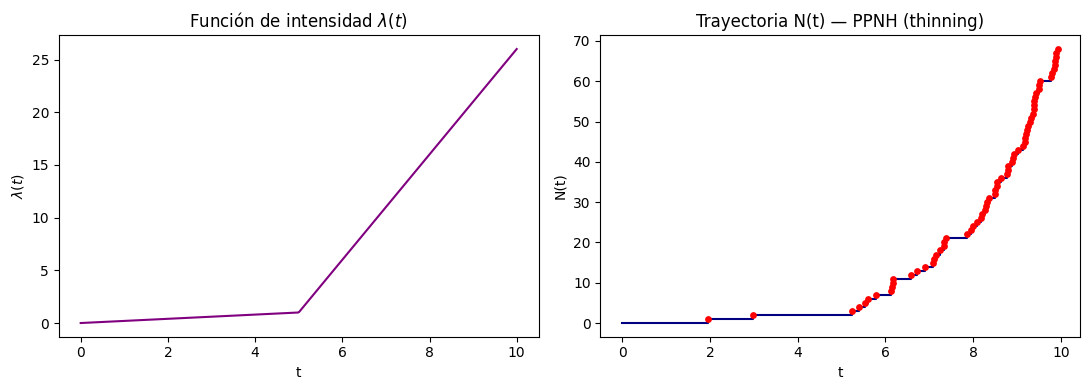

In [ ]:
def lambda_t(t):
    t = np.asarray(t, dtype=float)
    return np.where(t < 5, t/5, 1 + 5*(t-5))

T_max = 10
lam_star = lambda_t(np.array([T_max - 1e-9]))[0]   # cota superior de lambda(t) en (0,10)
print("lambda* (cota superior) =", lam_star)

def ppnh_thinning(gen, T, lam_star, lam_func):
    t = 0.0
    arribos = []
    while True:
        u1 = gen.uniform()
        t = t - np.log(u1) / lam_star
        if t > T:
            break
        u2 = gen.uniform()
        if u2 <= lam_func(np.array([t]))[0] / lam_star:
            arribos.append(t)
    return np.array(arribos)

gen_nhpp = GeneradorCongruencialMixto(seed=rng_state_seed + 10)
arribos_nhpp = ppnh_thinning(gen_nhpp, T_max, lam_star, lambda_t)

print(f"\nSe generaron {len(arribos_nhpp)} eventos en (0, {T_max}]")
print("Tiempos de arribo:", np.round(arribos_nhpp, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t_grid = np.linspace(0, 10, 400)
axes[0].plot(t_grid, lambda_t(t_grid), color='purple')
axes[0].set_title('Función de intensidad $\\lambda(t)$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('$\\lambda(t)$')

axes[1].step(np.concatenate(([0], arribos_nhpp)), np.arange(0, len(arribos_nhpp)+1),
             where='post', color='navy')
axes[1].scatter(arribos_nhpp, np.arange(1, len(arribos_nhpp)+1), color='red', s=15, zorder=5)
axes[1].set_title('Trayectoria N(t) — PPNH (thinning)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('N(t)')
plt.tight_layout(); plt.savefig('nhpp.png', dpi=120); plt.show()


Se nota que casi no pasa nada en la primera mitad del intervalo, donde $\lambda(t)$ es baja,
y que los eventos se van acumulando cada vez más rápido a medida que se acerca a $t=10$, que es
justo donde la intensidad es mayor. Eso es exactamente lo que se esperaba del método de
adelgazamiento: la forma de $\lambda(t)$ queda reflejada en qué tan seguido aparecen los eventos.


## 5. Conclusiones

- El generador congruencial mixto que se implementó pasó tanto la prueba de uniformidad como la de
  independencia, así que sirvió como base confiable para el resto de la práctica en lugar de usar
  un generador ya hecho.
- El método de la transformada inversa funcionó bien para las cuatro distribuciones de la Sección
  5.1: en todos los casos el histograma quedó muy pegado a la curva teórica.
- El método polar permitió generar normales estándar sin tener que calcular seno ni coseno,
  apoyándose en un rechazo geométrico dentro del círculo unitario.
- En el proceso de Poisson homogéneo el número de eventos salió cerca de lo esperado ($\lambda T$),
  y en el proceso no homogéneo el método de adelgazamiento reflejó bien la forma variable de
  $\lambda(t)$: más eventos donde la intensidad es más alta.
- La variable de Coxian sirvió para ilustrar un caso más realista de tiempos de servicio, donde el
  "cliente" (o trabajador, en este caso) puede abandonar el proceso antes de completar todas las
  etapas.

En general, los resultados obtenidos concuerdan con lo que predice la teoría, lo que da confianza
en que las implementaciones están correctas.

## 6. Bibliografía

[Ross13] Ross, Sheldon. *Simulation*, Fifth Edition. Pearson Press, 2013.
